DCIT407 Semester Project
Edge-Based Image Segmentation Using Canny Edge Detection

️1️⃣ Introduction

Image segmentation is the process of dividing an image into meaningful regions to simplify analysis. It plays a critical role in computer vision tasks such as object detection, medical imaging, autonomous driving, and surveillance.

One common approach to segmentation is edge-based segmentation, where object boundaries are detected first and then used to define regions.

In this project, we implement edge-based segmentation using the Canny edge detection algorithm. The Canny method is widely recognized for its accuracy, noise robustness, and ability to produce thin and well-localized edges.

##  2️⃣Theoretical Background

### 2.1 Edge Detection
Edges represent sharp intensity changes in an image. If the image intensity function is $I(x, y)$, edges occur where the gradient is large:

$$G_x = \frac{\partial I}{\partial x}, \quad G_y = \frac{\partial I}{\partial y}$$

The gradient magnitude is:
$$G = \sqrt{G_x^2 + G_y^2}$$

Large values of $G$ indicate strong edges.

### 2.2 Canny Edge Detection Algorithm
The Canny algorithm was developed by John F. Canny in 1986. It consists of five major steps:

#### Step 1: Gaussian Smoothing
Noise reduction is performed using a Gaussian filter to prevent the algorithm from mistaking "image noise" for actual edges.

The mathematical formula for the Gaussian kernel is:
$$G(x,y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2 + y^2}{2\sigma^2}}$$

**Where:**
* $\sigma$ (Sigma) controls the amount of smoothing.
* $x$ and $y$ are the distances from the origin in the horizontal and vertical axes.

Step 2: Gradient ComputationThe algorithm finds the intensity gradients of the image by applying Sobel operators in both horizontal ($G_x$) and vertical ($G_y$) directions. This reveals where the pixel intensity changes most sharply.Gradient Magnitude ($G$): This represents the strength of the edge at each pixel.$$G = \sqrt{G_x^2 + G_y^2}$$Edge Direction ($\theta$): This helps the algorithm understand the orientation of the edge, which is necessary for the next step (Non-Maximum Suppression).$$\theta = \tan^{-1}\left(\frac{G_y}{G_x}\right)$$

Step 3: Non-Maximum Suppression

Only local maximum pixels along the gradient direction are retained.
This produces thin edges.

Step 4: Double Thresholding

Two thresholds classify edges into:

Strong edges

Weak edges

Non-edges

Step 5: Edge Tracking by Hysteresis

Weak edges connected to strong edges are preserved.
Isolated weak edges are removed.

2.3 Edge-Based Segmentation

After detecting edges, segmentation is achieved by extracting contours. Contours represent object boundaries and allow us to separate foreground objects from the background.

3️⃣. Methodology

The following procedure was used:

Load the image.

Convert image to grayscale.

Apply Gaussian blur to reduce noise.

Apply Canny edge detection.

Extract contours from edges.

Draw contours to segment objects.

Compare results.

Libraries used:

OpenCV

NumPy

Matplotlib

Image loaded successfully.


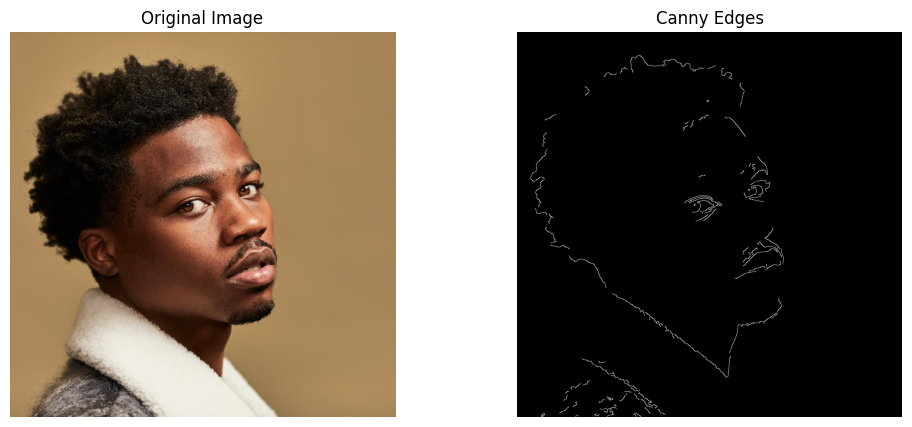

In [7]:
# 4️⃣ implementation

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
image = cv2.imread('sample.jpg')

# Check if image loaded
if image is None:
    print("Error: Image not found.")
else:
    print("Image loaded successfully.")

# Convert to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur
blur = cv2.GaussianBlur(gray, (5,5), 1.4)

# Apply Canny edge detection
edges = cv2.Canny(blur, 100, 200)

# Display original and edges
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image_rgb)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Canny Edges")
plt.imshow(edges, cmap='gray')
plt.axis("off")

plt.show()


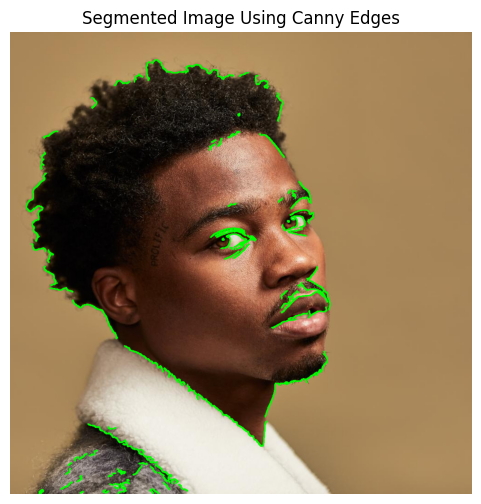

In [8]:
# 4️⃣  Contour based segmentation
# Find contours
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Copy image
segmented = image_rgb.copy()

# Draw contours
cv2.drawContours(segmented, contours, -1, (0,255,0), 2)

# Display segmented image
plt.figure(figsize=(6,6))
plt.title("Segmented Image Using Canny Edges")
plt.imshow(segmented)
plt.axis("off")
plt.show()


5️⃣ Results

The Canny algorithm successfully detected object boundaries in the test image. Contour extraction allowed segmentation of major objects from the background.

Lower thresholds detected more edges but introduced noise. Higher thresholds reduced noise but sometimes removed weak edges.

This demonstrates the importance of proper threshold selection.

6️⃣ Discussion
Strengths

High edge localization accuracy

Noise reduction capability

Produces thin and continuous edges

Widely used in real-world applications

Limitations

Sensitive to threshold selection

May fail in low-contrast images

Requires additional steps for full region segmentation

Real-World Applications

Medical image analysis

Autonomous driving systems

Industrial inspection

Face detection

Surveillance systems

7️⃣ Conclusion

This project implemented edge-based image segmentation using the Canny edge detection algorithm. The method effectively detected object boundaries and enabled segmentation through contour extraction. Although parameter tuning is necessary, Canny remains one of the most reliable edge detection techniques in digital image processing.